# Import libraries

In [104]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Load dataset

In [105]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Clean dataset

In [106]:
# Keep only required columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Convert labels

In [107]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Train-test split

In [108]:
df['text'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
5567    False
5568    False
5569    False
5570    False
5571    False
Name: text, Length: 5572, dtype: bool

# Text vectorization

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [110]:
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Train model

In [111]:
cv = CountVectorizer()

X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

# Prediction & accuracy

In [112]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [113]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9838565022421525


# Test your own message

In [114]:
msg = ["Congratulations! You won a free lottery"]

msg_vec = cv.transform(msg)

print("Prediction:", model.predict(msg_vec))

Prediction: [1]


# Classification Report 

In [115]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



#  Confusion Matrix

In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[963   2]
 [ 16 134]]


# Visualize Confusion Matrix

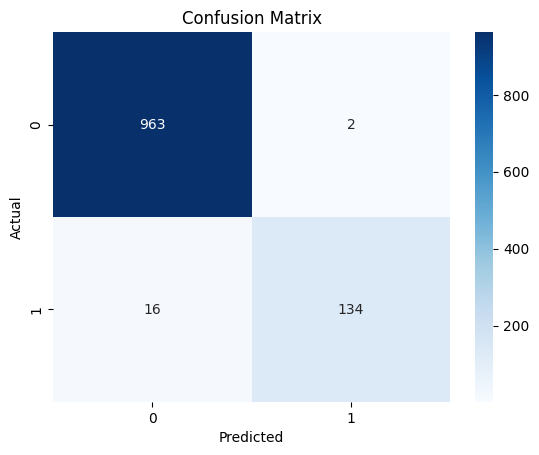

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Compare with TF-IDF

In [118]:
# X_train_raw = X_train
# X_test_raw = X_test

In [119]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

In [120]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))

TF-IDF Accuracy: 0.9623318385650225


In [121]:
msgs = [
    "Win ₹5000 now!!!",
    "Let's meet tomorrow",
    "Free entry in contest",
    "Call me when you reach"
]

for msg in msgs:
    print(msg, "->", model.predict(cv.transform([msg])))

Win ₹5000 now!!! -> [1]
Let's meet tomorrow -> [0]
Free entry in contest -> [1]
Call me when you reach -> [0]


In [122]:
user_msg = input("Enter message: ")

print("Prediction:", model.predict(cv.transform([user_msg])))

Prediction: [0]


In [123]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



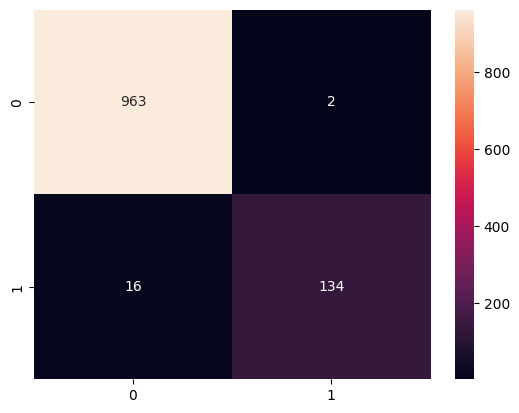

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()